# ENGR 1451/2451 — Weekly Assignment 5
**10 points**

Practice loading a CSV file, selecting complete observations, calculating correlations, making scatterplots and a correlation heat map, and writing a reusable function to compare individual and grouped data.

**Due:** See Canvas.

Complete the work directly in this notebook. Show your Python code and give brief written explanations where requested.

## What to hand in

Work this assignment with the **course tutor** in the class project. Use the course tutor as your AI help for this assignment; it keeps the record for you, so you do not need to write a separate log.

At the end of each working session, type **"make my record"** in the chat. Copy the block it produces and paste it into the **Session records** cell near the bottom of this notebook.

You do not have to finish in one sitting. To continue later, start a new chat in the same project, state which assignment you are working on and where you stopped, and continue from there. Paste the new session record below the previous one.

Session records are not graded for correctness or for how much help you needed. The code and written answers must still be your own.

## Setup

LE5-2 uses the supplied **`data/penguins.csv`** file. Keep the `data` folder beside this notebook. Use the folder containing the notebook as the working directory. The other exercises retain the embedded synthetic teaching data.

Select observations by conditions, not row positions. Calculate counts and cutoffs from the data. Label scatterplot axes with units. Keep written comments brief and tied to your calculated results.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
from IPython.display import display

## LE5-1. Compare laptop measurements (3 pts)

Each row describes one laptop. `battery_Wh` is battery capacity in watt-hours, `mass_kg` is mass in kilograms, and `runtime_h` is measured battery runtime in hours. Two entries are missing.

### A. Select complete observations (1 pt)

Create `complete` by selecting the three columns in `feature_cols` and dropping rows missing **any** of them. Report the number of laptops retained and excluded, using counts calculated from the data.

In [2]:
battery_Wh = [36, 42, 45, 48, 54, 60, 63, 66,
              72, 75, 78, 84, 90, 96, np.nan, 80]
laptops = pd.DataFrame({
    "battery_Wh": battery_Wh,
    "mass_kg": [1.2, 1.1, 1.6, 1.2, 1.5, 1.3, 1.4, 1.8,
                1.5, 1.6, 1.9, 2.0, 1.7, 2.1, 1.8, 2.0],
    "runtime_h": [4.1, 6.0, 5.4, 7.6, 6.5, 8.4, 6.9, 9.8,
                  8.2, 8.0, 10.5, 9.3, 11.6, 10.0, 8.5, np.nan],
})
laptop_labels = {
    "battery_Wh": "Battery capacity (Wh)",
    "mass_kg": "Mass (kg)",
    "runtime_h": "Battery runtime (h)",
}
feature_cols = list(laptop_labels)
laptop_settings = {
    "lower_quantile": 0.25,
    "upper_quantile": 0.75,
}

# Your complete-case selection and retained/excluded counts here
complete = laptops[feature_cols].dropna()
num_retained = len(complete)
num_excluded = len(laptops)-num_retained

print(num_retained, "retained\n",
      num_excluded, "excluded")
complete.head()

14 retained
 2 excluded


,battery_Wh,mass_kg,runtime_h
0,36.0,1.2,4.1
1,42.0,1.1,6.0
2,45.0,1.6,5.4
3,48.0,1.2,7.6
4,54.0,1.5,6.5


### B. Plot a pair (1 pt)

Using `complete`, make a scatterplot of **battery capacity** on the x-axis and **runtime** on the y-axis. Calculate Pearson's $r$. Describe the direction and shape of the plotted association in one sentence.

**Answer:** The association between battery capacity and runtime is positive, linear, and strong (r=0.878).

r = 0.878


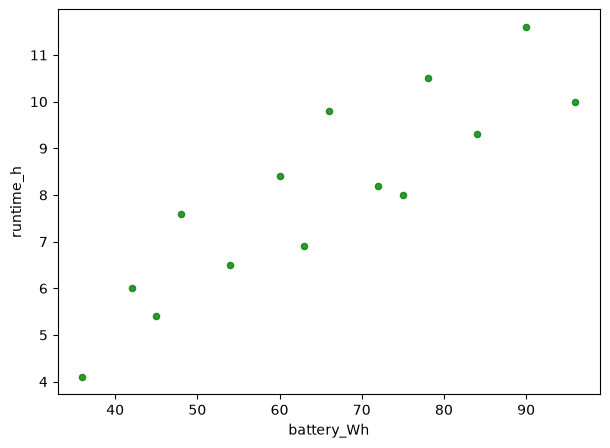

In [3]:
xcol = "battery_Wh"
ycol = "runtime_h"

# Your scatterplot and Pearson correlation here
ax = complete.plot.scatter(
    x=xcol,
    y=ycol,
    figsize=(7,5),
    alpha=0.8,
    color = "green",
)
complete_r = complete[xcol].corr(complete[ycol])
print("r =",round(complete_r,4))

### C. Restrict the range (1 pt)

Calculate the battery-capacity cutoffs at the quantiles specified in `laptop_settings`. Create `restricted` using `.loc[]` and `&` to keep capacities **between those cutoffs, including both endpoints**. Do not hard-code the cutoffs.

Display one table comparing the number of observations $n$ and the battery-capacity/runtime correlation $r$ for `complete` and `restricted`. Briefly report how $r$ changed.

**Answer:** The value of r for the restricted dataframe (r=0.438) is significantly less than the r for complete (r=0.878)

In [4]:
# Your data-derived cutoffs, Boolean filter, and n/r comparison here
battery_capacity_lower_cutoff = complete["battery_Wh"].quantile(laptop_settings["lower_quantile"])
battery_capacity_upper_cutoff = complete["battery_Wh"].quantile(laptop_settings["upper_quantile"])

mask_laptop_settings = (complete["battery_Wh"] > battery_capacity_lower_cutoff) & (complete["battery_Wh"] < battery_capacity_upper_cutoff)
restricted = complete[mask_laptop_settings]

restricted_r = restricted[xcol].corr(restricted[ycol])

comparison_table_LE5_1C = pd.DataFrame({
    "Number of observations": [len(complete),len(restricted)],
    "r": [complete_r,restricted_r]
},index = ["complete","restricted"])

comparison_table_LE5_1C.head()

,Number of observations,r
complete,14,0.878026
restricted,6,0.437600


## LE5-2. Cross-correlation matrix from a CSV file (3 pts)

Use the **Palmer Penguins** data in `data/penguins.csv`. Each row represents one penguin. Analyze the four physical measurements listed in `penguin_labels`; do not include species, island, sex, or year in the matrix.

Source: Horst, Hill, and Gorman, [palmerpenguins](https://allisonhorst.github.io/palmerpenguins/), with measurements collected by Kristen Gorman and Palmer Station LTER. [Variable definitions](https://allisonhorst.github.io/palmerpenguins/reference/penguins.html). The supplied CSV is the copy distributed with [plotnine](https://plotnine.org/reference/penguins.html); the data are licensed CC0. No additional package is needed to load the CSV.

### A. Load and prepare the data (1 pt)

Use `pd.read_csv()` to load `csv_path` into `penguins` and display its first few rows. Select `measurement_cols`, then drop rows missing **any of these four measurements**, storing the result as `penguin_complete`. Do not drop observations just because sex or another unused column is missing.

Report the number of rows loaded, retained, and excluded. Use the same `penguin_complete` observations throughout this exercise.

In [5]:
csv_path = Path("data/penguins.csv")
penguin_labels = {
    "bill_length_mm": "Bill length (mm)",
    "bill_depth_mm": "Bill depth (mm)",
    "flipper_length_mm": "Flipper length (mm)",
    "body_mass_g": "Body mass (g)",
}
measurement_cols = list(penguin_labels)

# Your pd.read_csv(), preview, complete-case selection, and counts here
penguins = pd.read_csv(csv_path)
penguin_complete = penguins[measurement_cols].dropna()

rows_loaded = len(penguins)
rows_retained = len(penguin_complete)
rows_excluded = rows_loaded-rows_retained

print("Loaded:",rows_loaded,
      "\nRetained:",rows_retained,
      "\nExcluded:",rows_excluded)

penguins.head()

Loaded: 344 
Retained: 342 
Excluded: 2


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


### B. Calculate and display the matrix (1 pt)

Calculate the **Pearson cross-correlation matrix** for all four columns of `penguin_complete` and name it `corr_matrix`. Here, the matrix contains the pairwise correlations between the measurement columns, not correlations at time lags. Display it rounded to three decimal places, keeping the unrounded matrix for plotting and subsequent calculations.

**The heat-map code is provided below; do not rewrite it.** Run the function-definition cell, then use `ax = plot_correlation_heatmap(corr_matrix)` after calculating your matrix. The fixed scale maps **−1 to dark red, 0 to white, and +1 to dark blue**.

In [6]:
# Provided plotting code: run this cell unchanged.
def plot_correlation_heatmap(corr_matrix):
    """Plot the student's matrix on a fixed red–white–blue scale."""
    cmap = LinearSegmentedColormap.from_list(
        "correlation_rwb", ["darkred", "white", "darkblue"], N=257
    )  # An odd palette size makes the middle color exactly white.

    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(
        corr_matrix, cmap=cmap, vmin=-1, vmax=1, interpolation="nearest"
    )
    positions = np.arange(len(corr_matrix.columns))
    labels = [penguin_labels[column] for column in corr_matrix.columns]
    ax.set_xticks(positions, labels=labels, rotation=45, ha="right")
    ax.set_yticks(positions, labels=labels)
    ax.set_title("Palmer Penguins: Pearson correlation matrix", pad=14)

    for (row, col), value in np.ndenumerate(corr_matrix.to_numpy()):
        ax.text(
            col, row, f"{value:.2f}", ha="center", va="center",
            color="white" if abs(value) > 0.5 else "black",
        )

    fig.colorbar(image, ax=ax, label="Pearson r", ticks=[-1, -0.5, 0, 0.5, 1])
    fig.tight_layout()
    plt.show()
    return ax

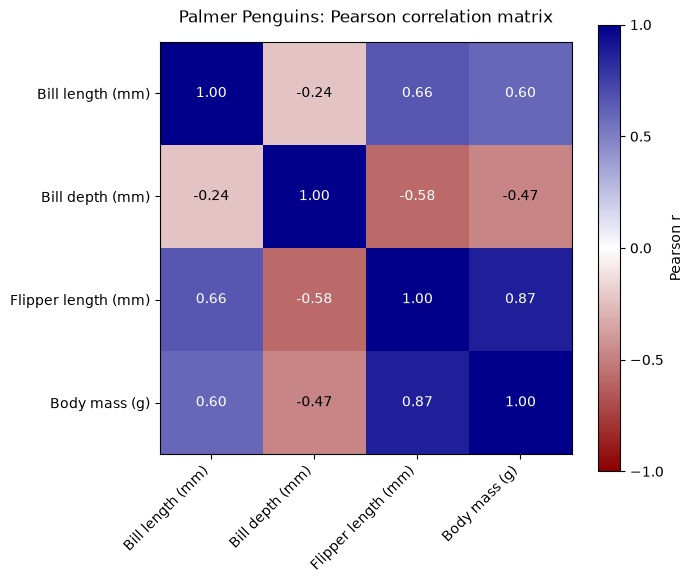

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000,-0.235,0.656,0.595
bill_depth_mm,-0.235,1.000,-0.584,-0.472
flipper_length_mm,0.656,-0.584,1.000,0.871
body_mass_g,0.595,-0.472,0.871,1.000


In [7]:
# Your corr_matrix calculation and rounded display here

# After calculating corr_matrix, uncomment the following line:
corr_matrix = penguin_complete.corr()
ax = plot_correlation_heatmap(corr_matrix)
corr_matrix.round(3) #displaying data rounded to 3-decimal places

### C. Select pairs and make a scatterplot (1 pt)

Use your matrix to identify the **strongest positive** and **strongest negative** correlations between distinct measurements. Ignore the diagonal and count each pair only once. Report both pairs and retrieve their correlations with `.loc[]`, rather than typing the correlation values by hand.

Make a scatterplot for whichever of these two pairs has the larger absolute correlation. Label the axes using `penguin_labels` and include its $r$ in the title.

Max r value = 0.8712017673060111 
 Row, Column: ('flipper_length_mm', 'body_mass_g')
Min r value = -0.2350528703555336 
 Row, Column: ('bill_depth_mm', 'bill_length_mm')


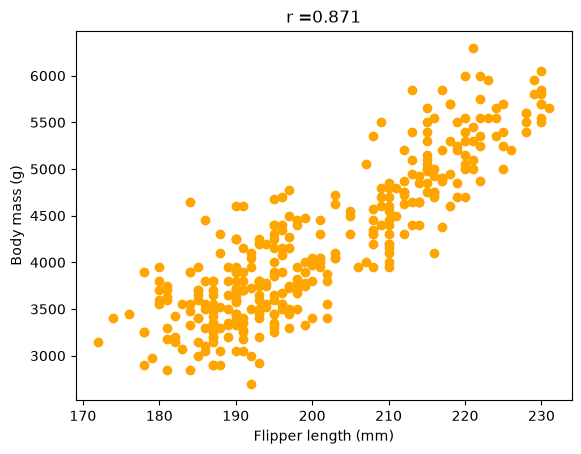

In [38]:
# Identify the two pairs and retrieve their r values from corr_matrix.
# Plot the pair with the larger absolute correlation.

#Automatically aquiring correlations - not neccesary
#corr_matrix_np = corr_matrix.to_numpy().copy()
#np.fill_diagonal(corr_matrix_np, np.nan) #replacing diagonals with nan - can't replace with a set number because it could mess with min/maxes
#max_corr_value = np.nanmax(corr_matrix_np) #ignores the nan values
#min_corr_value = np.nanmin(corr_matrix_np)

#Identifiying locations
max_titles = "flipper_length_mm","body_mass_g" #row,col
min_titles = "bill_depth_mm","bill_length_mm"
r_positive_max = corr_matrix.loc[max_titles] #row,col
r_negative_max = corr_matrix.loc[min_titles] 

print("Max r value =",r_positive_max,"\n Row, Column:",max_titles)
print("Min r value =",r_negative_max,"\n Row, Column:",min_titles)

def scatter_plot_2C(pair,r_value,dataset,labels):
    xcol,ycol = pair
    fig,ax = plt.subplots()
    ax.scatter(dataset[xcol],dataset[ycol],color="orange")
    ax.set_xlabel(labels[xcol])
    ax.set_ylabel(labels[ycol])
    ax.set_title("r ="+str(round(r_value,3)))

#Determining the stronger absolute correlation and plotting it
max_or_min = abs(r_positive_max) > abs(r_negative_max)
if(max_or_min): #positive > negative
    scatter_plot_2C(max_titles,r_positive_max,penguin_complete,penguin_labels)
else:
    scatter_plot_2C(min_titles,r_negative_max,penguin_complete,penguin_labels)


## LE5-3. Compare a curved pattern with an added observation (2 pts)

A process-development team records product yield at several temperatures. Each row is one run. `yield_pct` is the percentage of starting material recovered as the desired product.

### A. Plot the original runs (1 pt)

Plot temperature on the x-axis and yield on the y-axis, then calculate Pearson's $r$. Use a condition on `yield_pct` to display the run or runs with the highest observed yield. Briefly describe the plotted pattern.

**Answer:** The plotted pattern appears to have a downturned polynomial pattern.

r = 0.0075451107882686915
Max yield:  95


,Run #,temperature_C,yield_pct
0,4,50,95


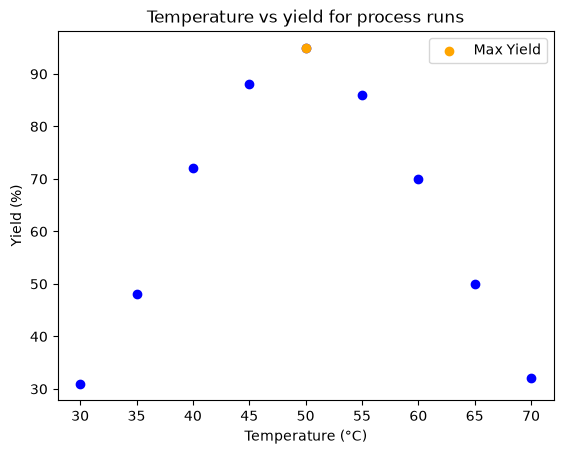

In [101]:
runs = pd.DataFrame({
    "temperature_C": [30, 35, 40, 45, 50, 55, 60, 65, 70],
    "yield_pct": [31, 48, 72, 88, 95, 86, 70, 50, 32],
})

# Your scatterplot, Pearson correlation, and maximum-yield run selection here
xtitle = "temperature_C"
ytitle = "yield_pct"
xaxis = runs[xtitle]
yaxis = runs[ytitle]

max_yield = yaxis.max()
max_yield_pos = runs.loc[runs["yield_pct"] == max_yield]
runs_correlation = xaxis.corr(yaxis)

fig, ax = plt.subplots()
ax.scatter(xaxis,yaxis, c = "blue")
ax.scatter(max_yield_pos[xtitle], max_yield, c = "orange", label="Max Yield")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Yield (%)")
ax.legend()
ax.set_title("Temperature vs yield for process runs")

print("r =",runs_correlation)
print("Max yield: ",max_yield)
max_yield_pos.reset_index().rename(columns={"index": "Run #"}) #changing display to include Run # on the same line
#max_yield_pos.head()

### B. Add one unusual observation (1 pt)

Use `pd.concat()` to combine `runs` and `extra_run` into a new DataFrame, `all_runs`; retain the original data.

Display one table comparing $n$ and $r$ for the original and combined data. Make a scatterplot of the combined data, marking the additional run with a different marker and adding a legend. Report the numerical change in $r$ (combined minus original).

Numerical change in r = -0.5662131995813564


Text(0.5, 1.0, 'Temperature vs yield for process runs (with extra run)')

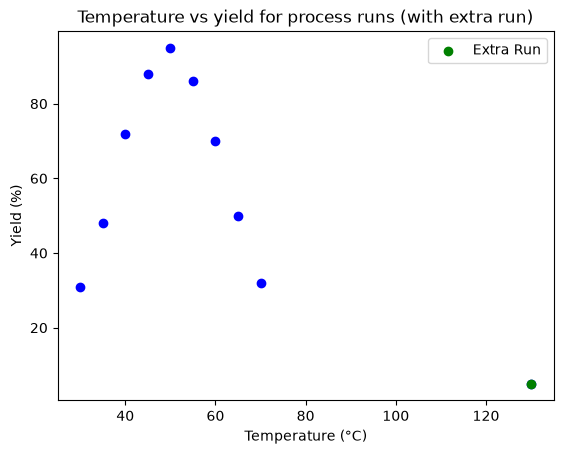

In [ ]:
extra_run = pd.DataFrame({"temperature_C": [130], "yield_pct": [5]})

# Your combined data, n/r comparison, and scatterplot here
all_runs = pd.concat([runs,extra_run])

#Scatterplot
xtitle = "temperature_C"
ytitle = "yield_pct"
xaxis = all_runs[xtitle]
yaxis = all_runs[ytitle]

runs_correlation_new = xaxis.corr(yaxis)
correlation_difference = runs_correlation_new - runs_correlation
print("Numerical change in r =",correlation_difference)

fig, ax = plt.subplots()
ax.scatter(xaxis,yaxis, c = "blue")
ax.scatter(extra_run[xtitle], extra_run[ytitle], c = "green", label="Extra Run")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Yield (%)")
ax.legend()
ax.set_title("Temperature vs yield for process runs (with extra run)")

#DISPLAY



## LE5-4. Write a function and use it twice (2 pts)

Each row below is one trainee in one of four workshops. The records give practice hours and an assembly assessment score on a 0–100 scale. These are synthetic observational records.

### A. Write and call your function (1 pt)

The individual and workshop-average analyses require the same scatterplot, count, and correlation. Write **`plot_and_summarize(data, title)`** to do that work once in a reusable function.

Your function must:

1. Create and display a **new scatterplot** of `practice_hours` on the x-axis and `assembly_score` on the y-axis. Label the axes **Practice hours (h)** and **Assembly score (0–100)**, and use the supplied `title`.
2. Calculate the number of rows $n$ and Pearson's $r$ from the supplied `data`.
3. **Return a `pd.Series`** with entries named `"n"` and `"r"`, rather than only printing them.

Use the `data` argument for every calculation and plot; do not refer to `trainees` or `workshop_means` inside the function. Do not hard-code the row count or correlation.

**First call:** Call your function on `trainees` with the title `"Individual trainees"`. Store its returned Series as `individual_summary` and display it. Write both the function body and the call yourself.

In [ ]:
trainees = pd.DataFrame({
    "workshop": ["A"] * 5 + ["B"] * 5 + ["C"] * 5 + ["D"] * 5,
    "practice_hours": [1, 3, 5, 7, 9, 3, 5, 7, 9, 11,
                       5, 7, 9, 11, 13, 7, 9, 11, 13, 15],
    "assembly_score": [52, 61, 46, 57, 54, 72, 57, 66, 62, 68,
                       72, 80, 65, 78, 70, 84, 76, 91, 80, 79],
})

def plot_and_summarize(data, title):
    """Plot practice hours versus score and return a Series containing n and r."""
    # Write your function body here.
    pass

# First call: analyze trainees and store the result as individual_summary.
# Display the returned Series.

0     A
1     A
2     A
3     A
4     A
5     B
6     B
7     B
8     B
9     B
10    C
11    C
12    C
13    C
14    C
15    D
16    D
17    D
18    D
19    D
Name: workshop, dtype: str


### B. Reuse the function for workshop averages (1 pt)

Use `.groupby(...).agg(...)` to create `workshop_means`, with one row per workshop showing its trainee count, mean practice hours, and mean assembly score. Name the count column `trainee_count`, and keep the two mean columns named **`practice_hours`** and **`assembly_score`** so the same function can analyze them. Display this table.

**Second call:** Call the **same function** on `workshop_means` with the title `"Workshop averages"`. Store its returned Series as `workshop_summary`. The returned $n$ now counts workshop rows, not individual trainees.

Use `individual_summary` and `workshop_summary` to create one labeled comparison table containing $n$ and $r$. Do not duplicate the scatterplot or correlation code outside the function. Briefly report how $r$ changed after aggregation.

**Answer:**

In [ ]:
# Create and display workshop_means using .groupby(...).agg(...).
# Keep the mean-column names practice_hours and assembly_score.

# Second call: analyze workshop_means and store the result as workshop_summary.

# Combine the two returned Series into a labeled n/r comparison table.

## Session records

At the end of each working session, type **"make my record"** in the chat and paste the block it produces into the cell below. If you work across several sessions, paste each new block underneath the previous one.

<!-- Paste your session record blocks in this cell, one after another. -->

*(session records go here)*
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA5",
  "export_n": 1,
  "session_date": "2026-10-04",
  "messages": [
    {"i": 1, "who": "student", "text": "For LE5 A\n\n```python\ncomplete = laptops[feature_cols].dropna()\nnum_retained = complete.count()\nnum_excluded = laptops.count()-num_retained\n\nprint(num_retained, \"retained\\n\",\n      num_excluded, \"excluded\")\ncomplete.head()\n```\n\nIs there a way to get the .count() function (or use a different function) to solely count the number of rows/observations overall instead of for each column?", "code": true},
    {"i": 2, "who": "tutor", "text": "Explained that `.count()` is column-wise (counts non-missing values per column), while `len(df)` or `df.shape[0]` give a single total row count. Gave a toy example contrasting the two, and asked the student to apply this to get the retained/excluded counts."},
    {"i": 3, "who": "student", "text": "That worked, thanks!"},
    {"i": 4, "who": "tutor", "text": "Confirmed the fix (swapping in a row-count function instead of a per-column one) and asked whether to continue with LE5-1A or move to part B."},
    {"i": 5, "who": "student", "text": "Can you outline the different scatter plot commands from all the different libraries covered so far in the course?"},
    {"i": 6, "who": "tutor", "text": "Outlined `ax.scatter()`, `ax.plot()` used with `linestyle=\"none\"`, and pandas' `.plot.scatter()`, with syntax examples and the tradeoffs of each, noting `ax.scatter()` via `plt.subplots()` is the one the course's assignments call for. Offered to show two `ax.scatter()` calls sharing one legend."},
    {"i": 7, "who": "student", "text": "Does this sentance effectively describe direction and shape of association? \n\n```markdown\n**Answer:** The association between battery capacity and runtime is positive, linear, and strong (r=0.878).\n```"},
    {"i": 8, "who": "tutor", "text": "Verified r = 0.878 against `complete` (n=14) via a reference calculation, confirmed the sentence satisfies the direction-and-shape requirement, and suggested the student double-check that the scatterplot itself (not just the r value) supports the \"linear\" claim before finalizing."},
    {"i": 9, "who": "student", "text": "How can I call the quantile values from the laptop settings dictionary?"},
    {"i": 10, "who": "tutor", "text": "Explained dictionary key access (`some_dict[\"key\"]`) with a toy example, noted the two keys `\"lower_quantile\"` and `\"upper_quantile\"` in `laptop_settings`, and asked if the student wanted `.quantile()` explained next or was ready to combine the pieces."},
    {"i": 11, "who": "student", "text": "make my record"}
  ],
  "events": [
    {"i": 1, "part": "5-1A", "type": "code"},
    {"i": 2, "part": "5-1A", "type": "explain"},
    {"i": 3, "part": "5-1A", "type": "part_pass"},
    {"i": 8, "part": "5-1B", "type": "part_pass"},
    {"i": 9, "part": "5-1C", "type": "explain"}
  ],
  "parts": [
    {"part": "5-1A", "exchanges": 2, "max_tier": 1, "passed": true},
    {"part": "5-1B", "exchanges": 1, "max_tier": 1, "passed": true},
    {"part": "5-1C", "exchanges": 1, "max_tier": 1, "passed": false}
  ],
  "tutor_assessment": [
    "No real sticking point this session — the .count()-vs-row-count mixup on 5-1A resolved in one exchange, and the 5-1B answer check passed on the first try.",
    "No escape-hatch or release-valve use this session; progress looked student-driven throughout."
  ]
}
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA5",
  "export_n": 2,
  "session_date": "2026-10-05",
  "messages": [
    {"i": 1, "who": "student", "text": "For LE5 A\n\n```python\ncomplete = laptops[feature_cols].dropna()\nnum_retained = complete.count()\nnum_excluded = laptops.count()-num_retained\n\nprint(num_retained, \"retained\\n\",\n      num_excluded, \"excluded\")\ncomplete.head()\n```\n\nIs there a way to get the .count() function (or use a different function) to solely count the number of rows/observations overall instead of for each column?", "code": true},
    {"i": 2, "who": "tutor", "text": "Explained that `.count()` is column-wise (counts non-missing values per column), while `len(df)` or `df.shape[0]` give a single total row count. Gave a toy example contrasting the two, and asked the student to apply this to get the retained/excluded counts."},
    {"i": 3, "who": "student", "text": "That worked, thanks!"},
    {"i": 4, "who": "tutor", "text": "Confirmed the fix and asked whether to continue with LE5-1A or move to part B."},
    {"i": 5, "who": "student", "text": "Can you outline the different scatter plot commands from all the different libraries covered so far in the course?"},
    {"i": 6, "who": "tutor", "text": "Outlined `ax.scatter()`, `ax.plot()` used with `linestyle=\"none\"`, and pandas' `.plot.scatter()`, noting `ax.scatter()` is the one the course's assignments call for. Offered to show a shared-legend example."},
    {"i": 7, "who": "student", "text": "Does this sentance effectively describe direction and shape of association? \n\n```markdown\n**Answer:** The association between battery capacity and runtime is positive, linear, and strong (r=0.878).\n```"},
    {"i": 8, "who": "tutor", "text": "Verified r = 0.878 against `complete` (n=14), confirmed the sentence met the direction-and-shape requirement, and suggested double-checking the plot itself supports \"linear.\""},
    {"i": 9, "who": "student", "text": "How can I call the quantile values from the laptop settings dictionary?"},
    {"i": 10, "who": "tutor", "text": "Explained dictionary key access with a toy example and named the two keys in `laptop_settings`. Asked if the student wanted `.quantile()` explained next."},
    {"i": 11, "who": "student", "text": "make my record"},
    {"i": 12, "who": "student", "text": "Does LE5 2B only require this single line of code?\n\n```python\ncorr_matrix = penguin_complete.corr(method=\"pearson\")\n```", "code": true},
    {"i": 13, "who": "tutor", "text": "Explained that the prompt also requires a rounded display (separate from `corr_matrix` itself) and the heat-map call, and noted `method=\"pearson\"` is redundant since it's the default."},
    {"i": 14, "who": "student", "text": "```python\ncorr_matrix = penguin_complete.corr()\nax = plot_correlation_heatmap(corr_matrix.round(3))\n\n\n```\n\nI tried changing the .round() number, but the display doesn't change (I keep seeing 1.00 instead of 1.000).", "code": true},
    {"i": 15, "who": "tutor", "text": "Pointed to the provided function's hardcoded `f\"{value:.2f}\"` as the reason rounding doesn't change the heat map's labels, clarified that the rounded display should be a separate table, and flagged that the heat-map call should use the unrounded `corr_matrix`, not the rounded version."},
    {"i": 16, "who": "student", "text": "Got it, thank you!"},
    {"i": 17, "who": "tutor", "text": "Confirmed the fix and asked whether to continue to LE5-2C or stop."},
    {"i": 18, "who": "student", "text": "Is there a way I can exclude a given value from corr_matrix.max() or min?"},
    {"i": 19, "who": "tutor", "text": "Explained `.where()` with `np.eye` and `np.fill_diagonal` on a copy as ways to mask the diagonal, with a toy example, and flagged the duplicate-pair issue in a full correlation matrix. Asked whether to show an upper-triangle mask or whether the student planned to read pairs off the display."},
    {"i": 20, "who": "student", "text": "How can I get the value of the max in the adjusted numpy matrix?\n\n```python\ncorr_matrix_np = corr_matrix.to_numpy().copy()\nnp.fill_diagonal(corr_matrix_np, np.nan)\nprint(corr_matrix_np)\n\nmax_val = corr_matrix_np.max()\n```", "code": true},
    {"i": 21, "who": "tutor", "text": "Explained that plain `.max()` propagates `nan` and that `np.nanmax()` (and `np.nanmin()`) skip them, with a toy example."},
    {"i": 22, "who": "student", "text": "Is there a way I can extract val, row, col from the max or min command?"},
    {"i": 23, "who": "tutor", "text": "Explained `np.nanargmax()`/`np.nanargmin()` plus `np.unravel_index()` to get row/column positions, with a toy example, and noted the position-vs-label distinction and the tie limitation."},
    {"i": 24, "who": "student", "text": "Is there not a more effective way of obtaining that information? I know MATLAB can pack it into a single command."},
    {"i": 25, "who": "tutor", "text": "Explained `.stack()` combined with `.idxmax()`/`.idxmin()` on a toy matrix, noting it still needs the diagonal handled first and the duplicate-pair issue from the full matrix."},
    {"i": 26, "who": "student", "text": "Is this actually what the first part of LE5 2C is asking for? I just want to make sure that I am doing the right thing."},
    {"i": 27, "who": "tutor", "text": "Clarified that LE5-2C only requires identifying the pairs (by eye is fine) and retrieving their values with `.loc[]` — the programmatic search discussed wasn't required, just one valid approach. Asked whether to continue building the automatic version or switch to the look-and-retrieve approach."},
    {"i": 28, "who": "student", "text": "make my record"}
  ],
  "events": [
    {"i": 1, "part": "5-1A", "type": "code"},
    {"i": 3, "part": "5-1A", "type": "part_pass"},
    {"i": 7, "part": "5-1B", "type": "part_pass"},
    {"i": 9, "part": "5-1C", "type": "explain"},
    {"i": 14, "part": "5-2B", "type": "code"},
    {"i": 16, "part": "5-2B", "type": "part_pass"},
    {"i": 18, "part": "5-2C", "type": "explain"},
    {"i": 20, "part": "5-2C", "type": "code"},
    {"i": 24, "part": "5-2C", "type": "explain"},
    {"i": 26, "part": "5-2C", "type": "explain"}
  ],
  "parts": [
    {"part": "5-1A", "exchanges": 2, "max_tier": 1, "passed": true},
    {"part": "5-1B", "exchanges": 1, "max_tier": 1, "passed": true},
    {"part": "5-1C", "exchanges": 1, "max_tier": 1, "passed": false},
    {"part": "5-2B", "exchanges": 3, "max_tier": 1, "passed": true},
    {"part": "5-2C", "exchanges": 5, "max_tier": 1, "passed": false}
  ],
  "tutor_assessment": [
    "Longest stall was LE5-2C: the student worked through several NumPy/pandas techniques for locating the max/min programmatically (fill_diagonal, nanargmax, stack/idxmax) before checking whether any of that was actually required, at which point it turned out a manual read-off with .loc[] would satisfy the prompt.",
    "Not a tutoring failure — the student was pursuing a more general technique out of curiosity and explicitly asked for a gut check before going further, which the tutor answered directly without discouraging the exploration."
  ]
}
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA5",
  "export_n": 3,
  "session_date": "2026-10-05",
  "messages": [
    {"i": 1, "who": "student", "text": "For LE5 A\n\n```python\ncomplete = laptops[feature_cols].dropna()\nnum_retained = complete.count()\nnum_excluded = laptops.count()-num_retained\n\nprint(num_retained, \"retained\\n\",\n      num_excluded, \"excluded\")\ncomplete.head()\n```\n\nIs there a way to get the .count() function (or use a different function) to solely count the number of rows/observations overall instead of for each column?", "code": true},
    {"i": 2, "who": "tutor", "text": "Explained that `.count()` is column-wise (counts non-missing values per column), while `len(df)` or `df.shape[0]` give a single total row count. Gave a toy example contrasting the two, and asked the student to apply this to get the retained/excluded counts."},
    {"i": 3, "who": "student", "text": "That worked, thanks!"},
    {"i": 4, "who": "tutor", "text": "Confirmed the fix and asked whether to continue with LE5-1A or move to part B."},
    {"i": 5, "who": "student", "text": "Can you outline the different scatter plot commands from all the different libraries covered so far in the course?"},
    {"i": 6, "who": "tutor", "text": "Outlined `ax.scatter()`, `ax.plot()` used with `linestyle=\"none\"`, and pandas' `.plot.scatter()`, noting `ax.scatter()` is the one the course's assignments call for. Offered to show a shared-legend example."},
    {"i": 7, "who": "student", "text": "Does this sentance effectively describe direction and shape of association? \n\n```markdown\n**Answer:** The association between battery capacity and runtime is positive, linear, and strong (r=0.878).\n```"},
    {"i": 8, "who": "tutor", "text": "Verified r = 0.878 against `complete` (n=14), confirmed the sentence met the direction-and-shape requirement, and suggested double-checking the plot itself supports \"linear.\""},
    {"i": 9, "who": "student", "text": "How can I call the quantile values from the laptop settings dictionary?"},
    {"i": 10, "who": "tutor", "text": "Explained dictionary key access with a toy example and named the two keys in `laptop_settings`. Asked if the student wanted `.quantile()` explained next."},
    {"i": 11, "who": "student", "text": "make my record"},
    {"i": 12, "who": "student", "text": "Does LE5 2B only require this single line of code?\n\n```python\ncorr_matrix = penguin_complete.corr(method=\"pearson\")\n```", "code": true},
    {"i": 13, "who": "tutor", "text": "Explained that the prompt also requires a rounded display (separate from `corr_matrix` itself) and the heat-map call, and noted `method=\"pearson\"` is redundant since it's the default."},
    {"i": 14, "who": "student", "text": "```python\ncorr_matrix = penguin_complete.corr()\nax = plot_correlation_heatmap(corr_matrix.round(3))\n\n\n```\n\nI tried changing the .round() number, but the display doesn't change (I keep seeing 1.00 instead of 1.000).", "code": true},
    {"i": 15, "who": "tutor", "text": "Pointed to the provided function's hardcoded `f\"{value:.2f}\"` as the reason rounding doesn't change the heat map's labels, clarified that the rounded display should be a separate table, and flagged that the heat-map call should use the unrounded `corr_matrix`."},
    {"i": 16, "who": "student", "text": "Got it, thank you!"},
    {"i": 17, "who": "tutor", "text": "Confirmed the fix and asked whether to continue to LE5-2C or stop."},
    {"i": 18, "who": "student", "text": "Is there a way I can exclude a given value from corr_matrix.max() or min?"},
    {"i": 19, "who": "tutor", "text": "Explained `.where()` with `np.eye` and `np.fill_diagonal` on a copy as ways to mask the diagonal, with a toy example, and flagged the duplicate-pair issue. Asked whether to show an upper-triangle mask or whether the student planned to read pairs off the display."},
    {"i": 20, "who": "student", "text": "How can I get the value of the max in the adjusted numpy matrix?\n\n```python\ncorr_matrix_np = corr_matrix.to_numpy().copy()\nnp.fill_diagonal(corr_matrix_np, np.nan)\nprint(corr_matrix_np)\n\nmax_val = corr_matrix_np.max()\n```", "code": true},
    {"i": 21, "who": "tutor", "text": "Explained that plain `.max()` propagates `nan` and `np.nanmax()`/`np.nanmin()` skip them, with a toy example."},
    {"i": 22, "who": "student", "text": "Is there a way I can extract val, row, col from the max or min command?"},
    {"i": 23, "who": "tutor", "text": "Explained `np.nanargmax()`/`np.nanargmin()` plus `np.unravel_index()`, with a toy example, noting the position-vs-label distinction and the tie limitation."},
    {"i": 24, "who": "student", "text": "Is there not a more effective way of obtaining that information? I know MATLAB can pack it into a single command."},
    {"i": 25, "who": "tutor", "text": "Explained `.stack()` combined with `.idxmax()`/`.idxmin()` on a toy matrix, noting the diagonal and duplicate-pair caveats."},
    {"i": 26, "who": "student", "text": "Is this actually what the first part of LE5 2C is asking for? I just want to make sure that I am doing the right thing."},
    {"i": 27, "who": "tutor", "text": "Clarified that LE5-2C only requires identifying the pairs (by eye is fine) and retrieving their values with `.loc[]`. Asked whether to continue building the automatic version or switch approaches."},
    {"i": 28, "who": "student", "text": "make my record"},
    {"i": 29, "who": "student", "text": "Is there any way to get the rows and columns if you already have the coefficient?"},
    {"i": 30, "who": "tutor", "text": "Explained searching with `toy == target` plus `.stack()` to get matching (row, col) label pairs, with a toy example, and flagged the floating-point equality risk versus finding the value directly via `.idxmax()`. Asked whether this was for the automatic approach or whether to switch to reading pairs by eye."},
    {"i": 31, "who": "student", "text": "Can you check if I missed any of the points of LE5 2C?\n\n```python\n#Identifiying locations\nmax_titles = \"body_mass_g\",\"flipper_length_mm\"\nmin_titles = \"bill_depth_mm\",\"bill_length_mm\"\nr_positive_max = corr_matrix.loc[max_titles] #row,col\nr_negative_max = corr_matrix.loc[min_titles] #row,col\n\ndef scatter_plot_2C(pair,r_value,dataset,labels):\n    xcol,ycol = pair\n    fig,ax = plt.subplots()\n    ax.scatter(dataset[xcol],dataset[ycol],color=\"orange\")\n    ax.set_xlabel(labels[xcol])\n    ax.set_ylabel(labels[ycol])\n    ax.set_title(\"r =\"+str(round(r_value,3)))\n\nmax_or_min = abs(r_positive_max) > abs(r_negative_max)\nif(max_or_min): #positive > negative\n    scatter_plot_2C(max_titles,r_positive_max,penguin_complete,penguin_labels)\nelse:\n    scatter_plot_2C(min_titles,r_negative_max,penguin_complete,penguin_labels)\n\n\n\n```", "code": true},
    {"i": 32, "who": "tutor", "text": "Verified `.loc[tuple]` correctly retrieves the scalar. Confirmed the scatterplot logic (new figure, labels, title with r, absolute-value comparison) looked structurally correct, but flagged that neither pair nor its r value is actually displayed/reported anywhere in the cell, and asked the student to confirm their pair identification against their own view of the matrix."},
    {"i": 33, "who": "student", "text": "make my record"}
  ],
  "events": [
    {"i": 1, "part": "5-1A", "type": "code"},
    {"i": 3, "part": "5-1A", "type": "part_pass"},
    {"i": 7, "part": "5-1B", "type": "part_pass"},
    {"i": 9, "part": "5-1C", "type": "explain"},
    {"i": 14, "part": "5-2B", "type": "code"},
    {"i": 16, "part": "5-2B", "type": "part_pass"},
    {"i": 18, "part": "5-2C", "type": "explain"},
    {"i": 20, "part": "5-2C", "type": "code"},
    {"i": 24, "part": "5-2C", "type": "explain"},
    {"i": 26, "part": "5-2C", "type": "explain"},
    {"i": 29, "part": "5-2C", "type": "explain"},
    {"i": 31, "part": "5-2C", "type": "code"}
  ],
  "parts": [
    {"part": "5-1A", "exchanges": 2, "max_tier": 1, "passed": true},
    {"part": "5-1B", "exchanges": 1, "max_tier": 1, "passed": true},
    {"part": "5-1C", "exchanges": 1, "max_tier": 1, "passed": false},
    {"part": "5-2B", "exchanges": 3, "max_tier": 1, "passed": true},
    {"part": "5-2C", "exchanges": 7, "max_tier": 2, "passed": false}
  ],
  "tutor_assessment": [
    "Longest stall was LE5-2C: the student explored several ways to programmatically locate the max/min pair (fill_diagonal, nanargmax, stack/idxmax, equality search) before confirming what the prompt actually required, then submitted code that handles the plotting correctly but is still missing a display of the two pairs and their r values.",
    "Not a tutoring failure — the exploration was student-initiated curiosity about general technique, clearly separated from the assignment requirement once asked, and the final code review was evidence-based rather than a draft handed to the student."
  ]
}
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA5",
  "export_n": 4,
  "session_date": "2026-10-05",
  "messages": [
    {"i": 1, "who": "student", "text": "For LE5 A\n\n```python\ncomplete = laptops[feature_cols].dropna()\nnum_retained = complete.count()\nnum_excluded = laptops.count()-num_retained\n\nprint(num_retained, \"retained\\n\",\n      num_excluded, \"excluded\")\ncomplete.head()\n```\n\nIs there a way to get the .count() function (or use a different function) to solely count the number of rows/observations overall instead of for each column?", "code": true},
    {"i": 2, "who": "tutor", "text": "Explained that `.count()` is column-wise (counts non-missing values per column), while `len(df)` or `df.shape[0]` give a single total row count. Gave a toy example contrasting the two, and asked the student to apply this to get the retained/excluded counts."},
    {"i": 3, "who": "student", "text": "That worked, thanks!"},
    {"i": 4, "who": "tutor", "text": "Confirmed the fix and asked whether to continue with LE5-1A or move to part B."},
    {"i": 5, "who": "student", "text": "Can you outline the different scatter plot commands from all the different libraries covered so far in the course?"},
    {"i": 6, "who": "tutor", "text": "Outlined `ax.scatter()`, `ax.plot()` used with `linestyle=\"none\"`, and pandas' `.plot.scatter()`, noting `ax.scatter()` is the one the course's assignments call for. Offered to show a shared-legend example."},
    {"i": 7, "who": "student", "text": "Does this sentance effectively describe direction and shape of association? \n\n```markdown\n**Answer:** The association between battery capacity and runtime is positive, linear, and strong (r=0.878).\n```"},
    {"i": 8, "who": "tutor", "text": "Verified r = 0.878 against `complete` (n=14), confirmed the sentence met the direction-and-shape requirement, and suggested double-checking the plot itself supports \"linear.\""},
    {"i": 9, "who": "student", "text": "How can I call the quantile values from the laptop settings dictionary?"},
    {"i": 10, "who": "tutor", "text": "Explained dictionary key access with a toy example and named the two keys in `laptop_settings`. Asked if the student wanted `.quantile()` explained next."},
    {"i": 11, "who": "student", "text": "make my record"},
    {"i": 12, "who": "student", "text": "Does LE5 2B only require this single line of code?\n\n```python\ncorr_matrix = penguin_complete.corr(method=\"pearson\")\n```", "code": true},
    {"i": 13, "who": "tutor", "text": "Explained that the prompt also requires a rounded display (separate from `corr_matrix`) and the heat-map call, and noted `method=\"pearson\"` is redundant since it's the default."},
    {"i": 14, "who": "student", "text": "```python\ncorr_matrix = penguin_complete.corr()\nax = plot_correlation_heatmap(corr_matrix.round(3))\n\n\n```\n\nI tried changing the .round() number, but the display doesn't change (I keep seeing 1.00 instead of 1.000).", "code": true},
    {"i": 15, "who": "tutor", "text": "Pointed to the provided function's hardcoded `f\"{value:.2f}\"` as the reason, clarified the rounded display should be separate, and flagged the heat-map call should use the unrounded `corr_matrix`."},
    {"i": 16, "who": "student", "text": "Got it, thank you!"},
    {"i": 17, "who": "tutor", "text": "Confirmed the fix and asked whether to continue to LE5-2C or stop."},
    {"i": 18, "who": "student", "text": "Is there a way I can exclude a given value from corr_matrix.max() or min?"},
    {"i": 19, "who": "tutor", "text": "Explained `.where()` with `np.eye` and `np.fill_diagonal` on a copy, with a toy example, and flagged the duplicate-pair issue. Asked whether to show an upper-triangle mask or whether the student planned to read pairs off the display."},
    {"i": 20, "who": "student", "text": "How can I get the value of the max in the adjusted numpy matrix?\n\n```python\ncorr_matrix_np = corr_matrix.to_numpy().copy()\nnp.fill_diagonal(corr_matrix_np, np.nan)\nprint(corr_matrix_np)\n\nmax_val = corr_matrix_np.max()\n```", "code": true},
    {"i": 21, "who": "tutor", "text": "Explained that plain `.max()` propagates `nan` and `np.nanmax()`/`np.nanmin()` skip them, with a toy example."},
    {"i": 22, "who": "student", "text": "Is there a way I can extract val, row, col from the max or min command?"},
    {"i": 23, "who": "tutor", "text": "Explained `np.nanargmax()`/`np.nanargmin()` plus `np.unravel_index()`, with a toy example, noting the position-vs-label distinction and tie limitation."},
    {"i": 24, "who": "student", "text": "Is there not a more effective way of obtaining that information? I know MATLAB can pack it into a single command."},
    {"i": 25, "who": "tutor", "text": "Explained `.stack()` combined with `.idxmax()`/`.idxmin()`, with a toy example, noting diagonal and duplicate-pair caveats."},
    {"i": 26, "who": "student", "text": "Is this actually what the first part of LE5 2C is asking for? I just want to make sure that I am doing the right thing."},
    {"i": 27, "who": "tutor", "text": "Clarified that LE5-2C only requires identifying the pairs (by eye is fine) and retrieving values with `.loc[]`. Asked whether to continue building the automatic version or switch approaches."},
    {"i": 28, "who": "student", "text": "make my record"},
    {"i": 29, "who": "student", "text": "Is there any way to get the rows and columns if you already have the coefficient?"},
    {"i": 30, "who": "tutor", "text": "Explained searching with `toy == target` plus `.stack()`, with a toy example, and flagged the floating-point equality risk versus `.idxmax()`. Asked whether this was for the automatic approach."},
    {"i": 31, "who": "student", "text": "Can you check if I missed any of the points of LE5 2C?\n\n```python\n#Identifiying locations\nmax_titles = \"body_mass_g\",\"flipper_length_mm\"\nmin_titles = \"bill_depth_mm\",\"bill_length_mm\"\nr_positive_max = corr_matrix.loc[max_titles] #row,col\nr_negative_max = corr_matrix.loc[min_titles] #row,col\n\ndef scatter_plot_2C(pair,r_value,dataset,labels):\n    xcol,ycol = pair\n    fig,ax = plt.subplots()\n    ax.scatter(dataset[xcol],dataset[ycol],color=\"orange\")\n    ax.set_xlabel(labels[xcol])\n    ax.set_ylabel(labels[ycol])\n    ax.set_title(\"r =\"+str(round(r_value,3)))\n\nmax_or_min = abs(r_positive_max) > abs(r_negative_max)\nif(max_or_min): #positive > negative\n    scatter_plot_2C(max_titles,r_positive_max,penguin_complete,penguin_labels)\nelse:\n    scatter_plot_2C(min_titles,r_negative_max,penguin_complete,penguin_labels)\n\n\n\n```", "code": true},
    {"i": 32, "who": "tutor", "text": "Verified `.loc[tuple]` retrieves the scalar correctly. Confirmed the scatterplot logic was structurally correct, but flagged that neither pair nor its r value is actually displayed/reported, and asked the student to confirm pair identification against their own view of the matrix."},
    {"i": 33, "who": "student", "text": "make my record"},
    {"i": 34, "who": "student", "text": "For LE5 3A, is there a way I can pass in a value to plot in a different color (like the max value) into the plt.scatter() function?"},
    {"i": 35, "who": "tutor", "text": "Explained plotting in two layered `ax.scatter()` calls with different colors, and the `c=` list-of-colors alternative, with toy examples. Clarified that LE5-3A's \"display\" requirement doesn't require a color highlight — asked if the student was adding it as an extra."},
    {"i": 36, "who": "student", "text": "Is there a way to get the position in the list/index of the max?"},
    {"i": 37, "who": "tutor", "text": "Explained `list.index()`, `.idxmax()`, and `np.argmax()`, each returning only the first match. Connected this to why LE5-3A's \"run or runs\" wording points toward a condition instead, to catch ties."},
    {"i": 38, "who": "student", "text": "Will .index return a tuple if multiple values are equal to the value passed into the function?"},
    {"i": 39, "who": "tutor", "text": "Explained that `list.index()` always returns a single integer, first-match-only, never a tuple, with a toy demonstration, and reiterated why a Boolean condition catches every tied row instead."},
    {"i": 40, "who": "student", "text": "Can .loc be used?"},
    {"i": 41, "who": "tutor", "text": "Explained `.loc[]` with a Boolean condition catching every matching row, with a toy tie example, and connected it to the move LE5-3A is asking for."},
    {"i": 42, "who": "student", "text": "```python\nruns = pd.DataFrame({\n    \"temperature_C\": [30, 35, 40, 45, 50, 55, 60, 65, 70],\n    \"yield_pct\": [31, 48, 72, 88, 95, 86, 70, 50, 32],\n})\n\n# Your scatterplot, Pearson correlation, and maximum-yield run selection here\nxtitle = \"temperature_C\"\nytitle = \"yield_pct\"\nxaxis = runs[xtitle]\nyaxis = runs[ytitle]\n\nmax_yield = yaxis.max()\nmax_yield_pos = runs.loc[runs[\"yield_pct\"] == max_yield]\nruns_correlation = xaxis.corr(yaxis)\n\nfig, ax = plt.subplots()\nax.scatter(xaxis,yaxis, c = \"blue\")\nax.scatter(max_yield_pos[xtitle], max_yield, c = \"orange\", label=\"Max Yield\")\nax.set_xlabel(xtitle)\nax.set_ylabel(ytitle)\nax.legend()\nax.set_title(\"Temperature vs yield for process runs\")\n\nmax_yield_pos[[xtitle,ytitle]].head()\n```\n\nHow can I drop the index from the max_yield_pos display?", "code": true},
    {"i": 43, "who": "tutor", "text": "Explained `.to_string(index=False)` and `.reset_index(drop=True)` with a toy example. Flagged that `ax.set_xlabel`/`set_ylabel` use raw column names instead of unit-labeled text, a stated requirement. Noted everything else (condition-based max selection, correlation, layered scatter) looked solid."},
    {"i": 44, "who": "student", "text": "How could I label the index column?"},
    {"i": 45, "who": "tutor", "text": "Explained `.index.name = ...` and `.rename_axis()`, with a toy example, and suggested a descriptive name given the context."},
    {"i": 46, "who": "student", "text": "[uploaded screenshot of code with runs.index.name = \"Run #\" and axis labels with units applied] Is there a way to get the display table to display the new index name and columns in one line?", "code": true},
    {"i": 47, "who": "tutor", "text": "Verified via a toy test that the two-line layout (index name above column headers) happens with both `print()` and `display()`, so it isn't Jupyter-specific. Explained `.reset_index()` plus `.rename(columns={...})` as a way to turn the index into a regular column sitting on the same header row, noting the tradeoff that it's no longer a true index."},
    {"i": 48, "who": "student", "text": "[uploaded screenshot showing max_yield_pos.reset_index().rename(columns={\"index\": \"Run #\"}) followed by max_yield_pos.head(), output still showing old index] Is there a way to get the display table to display the new index name and columns in one line?", "code": true},
    {"i": 49, "who": "tutor", "text": "Explained that only the last bare expression in a cell displays automatically, so the renamed line's result was being discarded while `.head()` on the original `max_yield_pos` displayed instead. Suggested reordering or storing the renamed version in a variable to display last."},
    {"i": 50, "who": "student", "text": "```python\nextra_run = pd.DataFrame({\"temperature_C\": [130], \"yield_pct\": [5]})\n\n# Your combined data, n/r comparison, and scatterplot here\nall_runs = pd.concat(runs,extra_run)\n```", "code": true},
    {"i": 51, "who": "tutor", "text": "Asked whether the student had run this and what error appeared. Explained that `pd.concat()` expects a list as its first argument, not two separate arguments, with a toy correction example, and flagged the default-index duplication to watch for once it runs."},
    {"i": 52, "who": "student", "text": "make my record"}
  ],
  "events": [
    {"i": 1, "part": "5-1A", "type": "code"},
    {"i": 3, "part": "5-1A", "type": "part_pass"},
    {"i": 7, "part": "5-1B", "type": "part_pass"},
    {"i": 9, "part": "5-1C", "type": "explain"},
    {"i": 14, "part": "5-2B", "type": "code"},
    {"i": 16, "part": "5-2B", "type": "part_pass"},
    {"i": 18, "part": "5-2C", "type": "explain"},
    {"i": 20, "part": "5-2C", "type": "code"},
    {"i": 24, "part": "5-2C", "type": "explain"},
    {"i": 26, "part": "5-2C", "type": "explain"},
    {"i": 29, "part": "5-2C", "type": "explain"},
    {"i": 31, "part": "5-2C", "type": "code"},
    {"i": 34, "part": "5-3A", "type": "explain"},
    {"i": 36, "part": "5-3A", "type": "explain"},
    {"i": 38, "part": "5-3A", "type": "explain"},
    {"i": 40, "part": "5-3A", "type": "explain"},
    {"i": 42, "part": "5-3A", "type": "code"},
    {"i": 50, "part": "5-3B", "type": "code"}
  ],
  "parts": [
    {"part": "5-1A", "exchanges": 2, "max_tier": 1, "passed": true},
    {"part": "5-1B", "exchanges": 1, "max_tier": 1, "passed": true},
    {"part": "5-1C", "exchanges": 1, "max_tier": 1, "passed": false},
    {"part": "5-2B", "exchanges": 3, "max_tier": 1, "passed": true},
    {"part": "5-2C", "exchanges": 7, "max_tier": 2, "passed": false},
    {"part": "5-3A", "exchanges": 6, "max_tier": 1, "passed": false},
    {"part": "5-3B", "exchanges": 1, "max_tier": 1, "passed": false}
  ],
  "tutor_assessment": [
    "LE5-2C remains the longest stall overall, but within this latest stretch LE5-3A took the most back-and-forth: the student explored list/Series/array ways to find a max's position before landing on the condition-based `.loc[]` approach the prompt wants, then hit display-formatting side-quests (dropping/renaming the index) that, while reasonable curiosity, delayed finishing the cell; the missing-units axis labels were caught and should still be fixed.",
    "Not a tutoring failure — all exploration was student-initiated and each question was answered directly; no release-valve or unstuck invocations occurred this session."
  ]
}

## Before you submit

1. **Restart Kernel and Run All Cells** and confirm that every cell runs without errors.
2. Confirm that all calculations, tables, and plots are visible in the saved notebook.
3. Confirm that your written answers are complete and your session record block(s) are pasted above.
4. Save the completed `.ipynb` file.
5. Submit the `.ipynb` file in Canvas.